In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
sns.set_palette('husl')

In [2]:
df = pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
mask = pd.to_numeric(df['TotalCharges'], errors = 'coerce').isna()
df[mask]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

In [6]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [7]:
df = df.drop(columns = 'customerID')

In [8]:
churn_rate = df['Churn'].value_counts(normalize=True)
churn_rate

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [9]:
df["SeniorCitizen"]= df["SeniorCitizen"].map({0: "No", 1: "Yes"})

In [10]:
cat_features = [i for i in list(df.columns) if i not in list(df.describe().columns)]

In [11]:
data = df.copy(deep=True)

In [12]:
bins = [0,6,12,18,24,36,48,60,72,1000]
bin_labels = ['0-6', '6-12', '12-18', '18-24', '24-36', '36-48', '48-60', '60-72', '72+']

data['tenure_group'] = pd.cut(data['tenure'], bins = bins, labels = bin_labels, right = False)

In [13]:
services = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in services:
    data[col] = data[col].replace({
        'Yes' : 1,
        'No' : 0,
        'No internet service' : 0
    })

data['HasInternet'] = (data['InternetService'] != 'No').astype(int)

In [14]:
data['NumServices'] = data[services].sum(axis=1)

In [15]:
data['ContractMonths'] = data['Contract'].map({
    'Month-to-month': 1,
    'One year': 12,
    'Two year' : 24
    
})

In [16]:
# Indicator
data['IsMonthToMonth'] = (data['Contract'] == 'Month-to-month').astype(int)

# Progress only for long-term
data['ContractProgress'] = np.where(
    data['Contract'] != 'Month-to-month',
    (data['tenure'] / data['ContractMonths']).clip(upper=1),
    np.nan
)

In [17]:
data['Churn'] = data['Churn'].map({
    'Yes':1,
    'No':0})

In [18]:
data['gender'] = data['gender'].map({'Male': 0, 'Female': 1})
data['SeniorCitizen'] = data['SeniorCitizen'].map({'No': 0, 'Yes': 1})

for col in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']:
    data[col] = data[col].map({'No': 0, 'Yes': 1})


data['MultipleLines'] = data['MultipleLines'].map({
    'No': 0,
    'Yes': 1,
    'No phone service': 0
})
data['HasPhoneService'] = (data['PhoneService'] == 'Yes').astype(int)

data = pd.get_dummies(data, columns=['InternetService', 'PaymentMethod'], drop_first=True)

bin_labels = ['0-6', '6-12', '12-18', '18-24', '24-36', '36-48', '48-60', '60-72', '72+']

data['tenure_group'] = data['tenure_group'].map({
    '0-6': 0,
    '6-12': 1,
    '12-18': 2,
    '18-24': 3,
    '24-36': 4,
    '36-48' : 5,
    '48-60':6,
    '60-72':7,
    '72+':8
})


In [19]:
data = pd.get_dummies(data, columns=['Contract'], drop_first=True)

In [20]:
bool_cols = data.select_dtypes(include = 'bool').columns
data[bool_cols] = data[bool_cols].astype(int)

In [21]:
data['tenure_group'] = data['tenure_group'].cat.as_ordered()

In [22]:
data['tenure_group'] = data['tenure_group'].cat.codes

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   MultipleLines                          7043 non-null   int64  
 7   OnlineSecurity                         7043 non-null   int64  
 8   OnlineBackup                           7043 non-null   int64  
 9   DeviceProtection                       7043 non-null   int64  
 10  TechSupport                            7043 non-null   int64  
 11  Stre

In [24]:
data['fiber_contract_risk'] = (
    data['InternetService_Fiber optic'] *
    data['IsMonthToMonth']
)

In [25]:
data['price_tenure_risk'] = (
    data['MonthlyCharges'] *
    (1 / (data['tenure'] + 1))
)

In [26]:
data['early_customer'] = (data['tenure'] <= 6).astype(int)

In [27]:
data['price_stress'] = (
    data['MonthlyCharges'] *
    data['IsMonthToMonth']
)

In [28]:
data['fiber_new_customer'] = (
    data['InternetService_Fiber optic'] *
    (data['tenure'] <= 6).astype(int)
)

In [29]:
data['ContractProgress'] = data['ContractProgress'].fillna(0)

In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 36 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   MultipleLines                          7043 non-null   int64  
 7   OnlineSecurity                         7043 non-null   int64  
 8   OnlineBackup                           7043 non-null   int64  
 9   DeviceProtection                       7043 non-null   int64  
 10  TechSupport                            7043 non-null   int64  
 11  Stre

In [31]:
from sklearn.model_selection import train_test_split

X = data.drop('Churn', axis=1)
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=42, stratify=y)

In [32]:
print("X_train", X_train.shape)
print("y_train", y_train.shape)
print("X_test", X_test.shape)
print("y_test", y_test.shape)

X_train (5282, 35)
y_train (5282,)
X_test (1761, 35)
y_test (1761,)


In [33]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [34]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train) 

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
lr = LogisticRegression(max_iter = 1000)
lr.fit(X_train_resampled, y_train_resampled)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

              precision    recall  f1-score   support

           0       0.91      0.74      0.81      1294
           1       0.52      0.79      0.63       467

    accuracy                           0.75      1761
   macro avg       0.71      0.76      0.72      1761
weighted avg       0.80      0.75      0.76      1761

ROC-AUC: 0.8516162555560337


In [36]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1294
           1       0.62      0.48      0.54       467

    accuracy                           0.78      1761
   macro avg       0.72      0.69      0.70      1761
weighted avg       0.77      0.78      0.77      1761

ROC-AUC: 0.8292373961191333


In [37]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1294
           1       0.62      0.51      0.56       467

    accuracy                           0.79      1761
   macro avg       0.73      0.70      0.71      1761
weighted avg       0.78      0.79      0.78      1761

ROC-AUC: 0.8186052245746304


In [38]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:,1]
y_pred_gb = (y_prob_gb > 0.5).astype(int)
print(classification_report(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))

              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1294
           1       0.65      0.48      0.55       467

    accuracy                           0.79      1761
   macro avg       0.74      0.69      0.71      1761
weighted avg       0.78      0.79      0.78      1761

ROC-AUC: 0.844084375589527


In [39]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
y_prob_nb = nb.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_nb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_nb))

              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1294
           1       0.49      0.81      0.61       467

    accuracy                           0.73      1761
   macro avg       0.70      0.75      0.70      1761
weighted avg       0.80      0.73      0.75      1761

ROC-AUC: 0.8377679555451119


In [40]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
y_pred_lda = lda.predict(X_test)
y_prob_lda = lda.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_lda))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lda))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1294
           1       0.65      0.55      0.60       467

    accuracy                           0.80      1761
   macro avg       0.75      0.72      0.73      1761
weighted avg       0.79      0.80      0.80      1761

ROC-AUC: 0.846593899036568


In [41]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

lr = Pipeline([
    ('scaler', StandardScaler()),
    ('SMOTE', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=1000))
    
])

gb = GradientBoostingClassifier(random_state=42)
lda = LinearDiscriminantAnalysis()

In [42]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('gb', gb),
        ('lda', lda)
    ],
    voting='soft'
)

ensemble.fit(X_train, y_train)

VotingClassifier(estimators=[('lr',
                              Pipeline(steps=[('scaler', StandardScaler()),
                                              ('SMOTE', SMOTE(random_state=42)),
                                              ('model',
                                               LogisticRegression(max_iter=1000))])),
                             ('gb',
                              GradientBoostingClassifier(random_state=42)),
                             ('lda', LinearDiscriminantAnalysis())],
                 voting='soft')

In [44]:
y_pred_voting = ensemble.predict(X_test)
y_prob_voting = ensemble.predict_proba(X_test)[:, 1]
y_pred_voting = (y_prob_voting > 0.36).astype(int)
print(classification_report(y_test, y_pred_voting))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_voting))

              precision    recall  f1-score   support

           0       0.90      0.77      0.83      1294
           1       0.55      0.78      0.64       467

    accuracy                           0.77      1761
   macro avg       0.73      0.77      0.74      1761
weighted avg       0.81      0.77      0.78      1761

ROC-AUC: 0.8512588160146153


In [45]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_voting)

In [46]:
import numpy as np

f1_scores = 2 * (precision * recall) / (precision + recall)
best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]

In [47]:
best_threshold

np.float64(0.36065794774704124)

In [48]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred_voting))

[[998 296]
 [105 362]]


In [49]:
lr = LogisticRegression()
lr.fit(X_train_resampled, y_train_resampled)

LogisticRegression()

In [50]:
import shap

explainer = shap.LinearExplainer(lr, X_train)
shap_values = explainer(X_test)

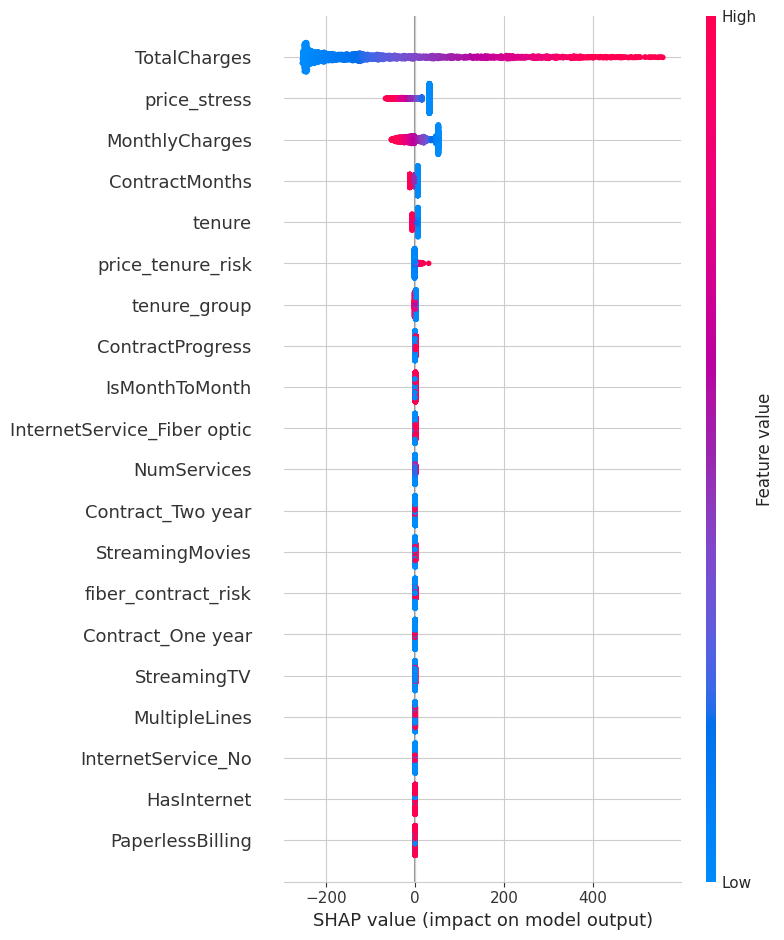

In [51]:
shap.summary_plot(shap_values, X_test)

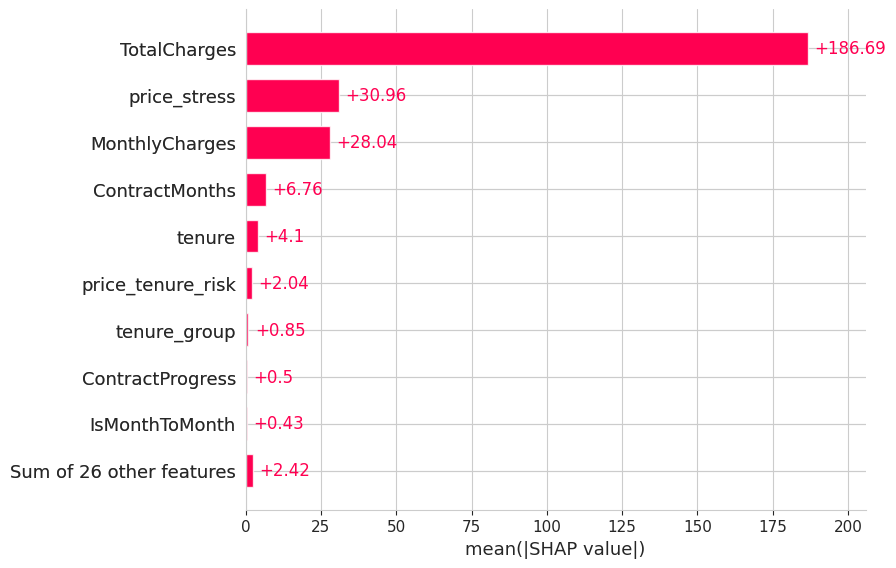

In [52]:
shap.plots.bar(shap_values)

In [53]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

LinearDiscriminantAnalysis()

In [54]:
explainer_lda = shap.LinearExplainer(lda, X_train)
shap_values = explainer_lda(X_test)

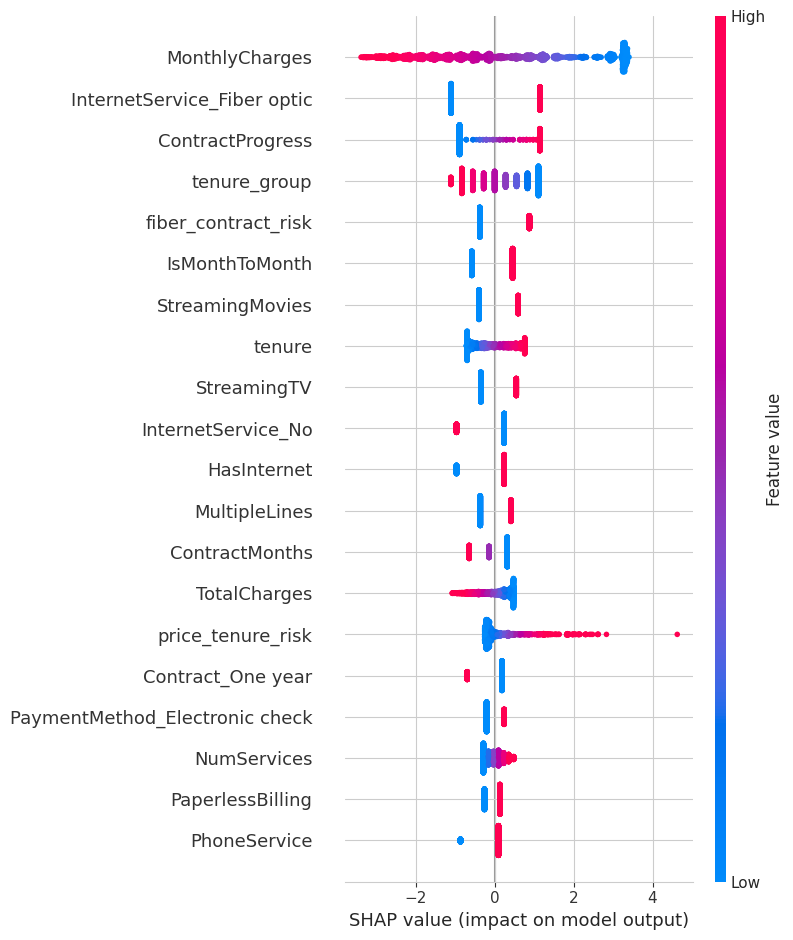

In [55]:
shap.summary_plot(shap_values, X_test)

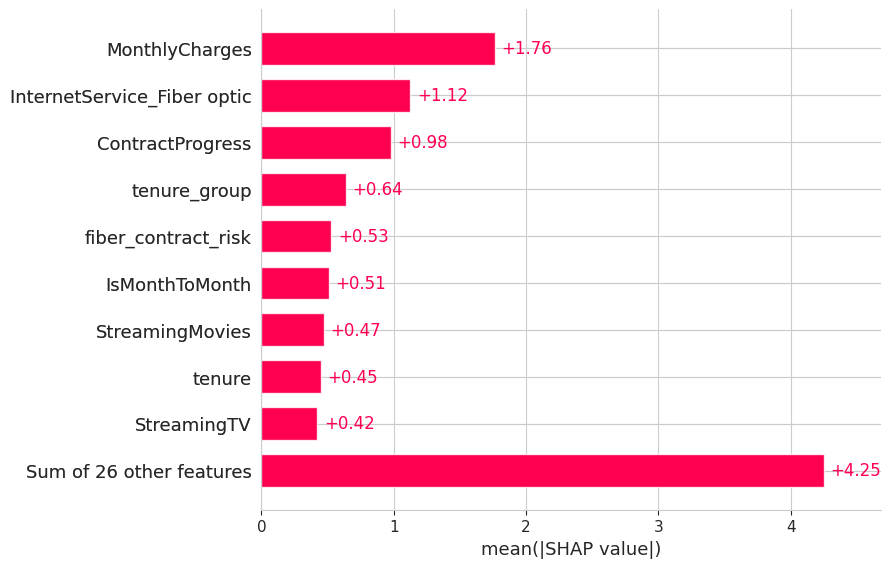

In [56]:
shap.plots.bar(shap_values)

In [57]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)


GradientBoostingClassifier(random_state=42)

In [58]:
explainer = shap.TreeExplainer(gb)
shap_values = explainer.shap_values(X_test, check_additivity=False)
shap_values = explainer(X_test)

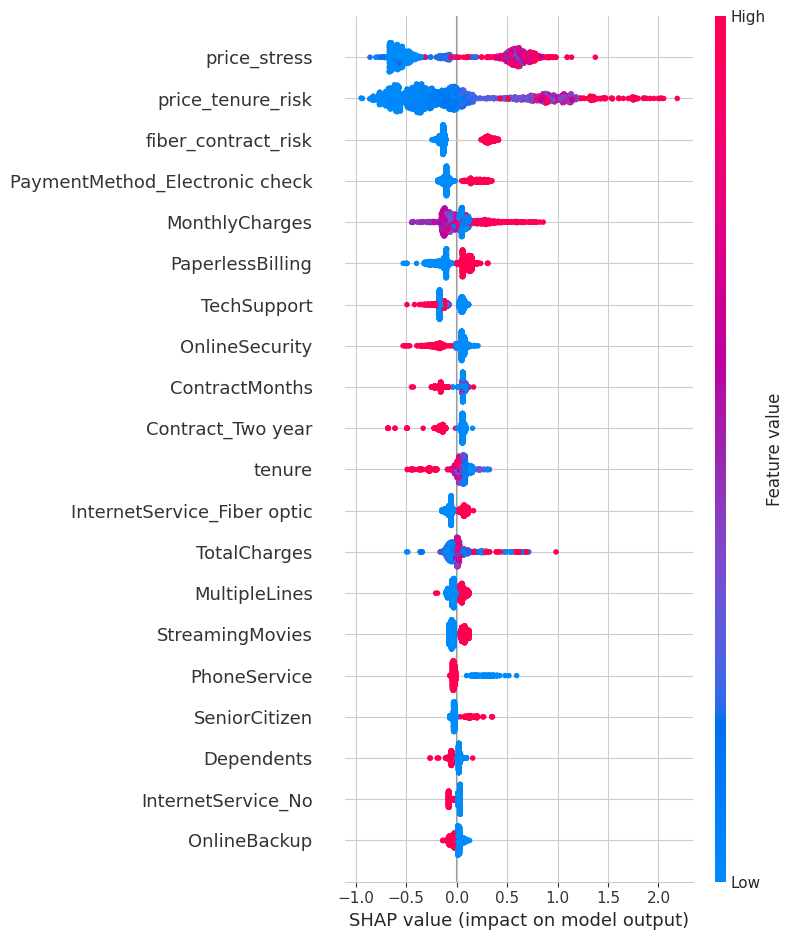

In [59]:
shap.summary_plot(shap_values, X_test)

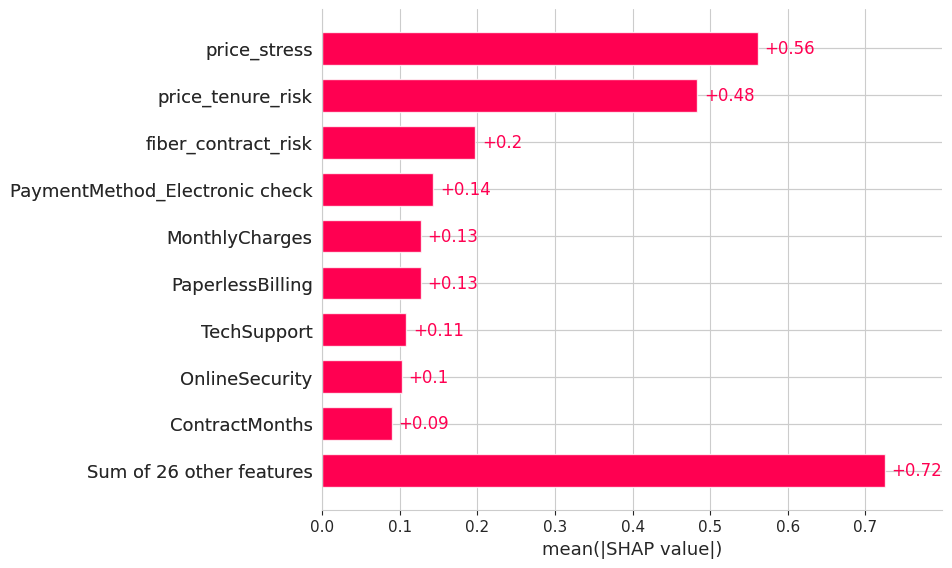

In [60]:
shap.plots.bar(shap_values)

In [ ]:
import optuna
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 2, 5),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0)
    }

    model = GradientBoostingClassifier(**params, random_state=42)
    score = cross_val_score(model, X_train, y_train, cv=3, scoring="roc_auc").mean()
    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

In [ ]:
print(study.best_params)
print("Best ROC-AUC:", study.best_value)

In [ ]:
import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

def objective(trial):

    params = {
        "C": trial.suggest_float("C", 0.01, 10, log=True),
        "penalty": trial.suggest_categorical("penalty", ["l2"]),
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        "solver": "lbfgs",
        "max_iter": 1000
    }

    model = LogisticRegression(**params)

    score = cross_val_score(
        model,
        X_train_resampled,
        y_train_resampled,
        cv=3,
        scoring="roc_auc"
    ).mean()

    return score

study_lr = optuna.create_study(direction="maximize")
study_lr.optimize(objective, n_trials=30)

In [ ]:
print(study_lr.best_params)
print("Best ROC-AUC:", study_lr.best_value)

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

def objective(trial):

    solver = trial.suggest_categorical("solver", ["svd", "lsqr"])

    params = {"solver": solver}

    if solver in ["lsqr"]:
        params["shrinkage"] = trial.suggest_categorical(
            "shrinkage", [None, "auto"]
        )

    model = LinearDiscriminantAnalysis(**params)

    score = cross_val_score(
        model,
        X_train_resampled,
        y_train_resampled,
        cv=3,
        scoring="roc_auc"
    ).mean()

    return score

study_lda = optuna.create_study(direction="maximize")
study_lda.optimize(objective, n_trials=20)

In [ ]:
print(study_lda.best_params)
print("Best ROC-AUC:", study_lda.best_value)

In [ ]:
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "random_state": 42,
        "eval_metric": "logloss",
        "use_label_encoder": False
    }

    model = XGBClassifier(**params)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=3,
        scoring="roc_auc"
    ).mean()

    return score

study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective, n_trials=50)

In [ ]:
print("Best Params:", study_xgb.best_params)
print("Best ROC-AUC:", study_xgb.best_value)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1200),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        "random_state": 42
    }

    model = RandomForestClassifier(**params)

    score = cross_val_score(
        model, X_train, y_train,
        cv=3,
        scoring="roc_auc"
    ).mean()

    return score

study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(objective, n_trials=50)

In [ ]:
print("Best Params:", study_rf.best_params)
print("Best ROC-AUC:", study_rf.best_value)

In [ ]:
from lightgbm import LGBMClassifier

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 2000),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 256),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "random_state": 42
    }

    model = LGBMClassifier(**params)

    score = cross_val_score(
        model, X_train, y_train,
        cv=3,
        scoring="roc_auc"
    ).mean()

    return score

study_lgb = optuna.create_study(direction="maximize")
study_lgb.optimize(objective, n_trials=50)

In [ ]:
print("Best Params:", study_lgb.best_params)
print("Best ROC-AUC:", study_lgb.best_value)

In [ ]:
from catboost import CatBoostClassifier

def objective(trial):

    params = {
        "iterations": trial.suggest_int("iterations", 300, 2000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-3, 10.0, log=True),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1),
        "random_strength": trial.suggest_float("random_strength", 0, 2),
        "verbose": 0,
        "random_seed": 42
    }

    model = CatBoostClassifier(**params)

    score = cross_val_score(
        model, X_train, y_train,
        cv=3,
        scoring="roc_auc"
    ).mean()

    return score
study_cat = optuna.create_study(direction="maximize")
study_cat.optimize(objective, n_trials=50)

In [ ]:
print("Best Params:", study_cat.best_params)
print("Best ROC-AUC:", study_cat.best_value)

In [61]:
import numpy as np
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier

In [62]:
lr = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(
        C=5.798940578807269,
        penalty="l2",
        class_weight=None,
        max_iter=1000
    ))
])
lda = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", LinearDiscriminantAnalysis(
        solver="svd"
    ))
])
xgb = XGBClassifier(
    n_estimators=764,
    max_depth=5,
    learning_rate=0.04607551690459038,
    subsample=0.6773600755467752,
    colsample_bytree=0.6451282110804014,
    gamma=4.075674198737807,
    min_child_weight=5,
    reg_lambda=0.09798975955171457,
    reg_alpha=0.01170826559589334,
    random_state=42,
    eval_metric="logloss"
)

In [63]:
ensemble = VotingClassifier(
    estimators=[
        ("lr", lr),
        ("lda", lda),
        ("xgb", xgb)
    ],
    voting="soft",
    weights=[2, 1, 2]  # LR + XGB slightly stronger
)

In [64]:
ensemble.fit(X_train, y_train)

VotingClassifier(estimators=[('lr',
                              Pipeline(steps=[('scaler', StandardScaler()),
                                              ('smote', SMOTE(random_state=42)),
                                              ('model',
                                               LogisticRegression(C=5.798940578807269,
                                                                  max_iter=1000))])),
                             ('lda',
                              Pipeline(steps=[('scaler', StandardScaler()),
                                              ('smote', SMOTE(random_state=42)),
                                              ('model',
                                               LinearDiscriminantAnalysis())])),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=...
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.04607551690459038,
                                            max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=5,
                                            max_leaves=None, min_child_weight=5,
                                            missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=764, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                 voting='soft', weights=[2, 1, 2])

In [65]:
y_pred = ensemble.predict(X_test)
y_proba = ensemble.predict_proba(X_test)[:, 1]

In [66]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

In [67]:
import numpy as np

f1_scores = 2 * (precision * recall) / (precision + recall)
best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]

In [68]:
best_threshold

np.float64(0.4569719217192777)

In [69]:
best_threshold = 0.43

y_final = (y_proba >= best_threshold).astype(int)

In [70]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_final))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.91      0.76      0.83      1294
           1       0.54      0.78      0.64       467

    accuracy                           0.77      1761
   macro avg       0.72      0.77      0.73      1761
weighted avg       0.81      0.77      0.78      1761

ROC-AUC: 0.8519852787862943


In [71]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(
    ensemble,
    method="isotonic",
    cv=3
)

calibrated_model.fit(X_train, y_train)

CalibratedClassifierCV(cv=3,
                       estimator=VotingClassifier(estimators=[('lr',
                                                               Pipeline(steps=[('scaler',
                                                                                StandardScaler()),
                                                                               ('smote',
                                                                                SMOTE(random_state=42)),
                                                                               ('model',
                                                                                LogisticRegression(C=5.798940578807269,
                                                                                                   max_iter=1000))])),
                                                              ('lda',
                                                               Pipeline(steps=[('scaler',
                                                                                StandardScaler()),
                                                                               ('smote',
                                                                                SMOTE(random_state=42)),
                                                                               ('model',
                                                                                LinearDiscriminantAnalysis())])),
                                                              ('xgb',...
                                                                             interaction_constraints=None,
                                                                             learning_rate=0.04607551690459038,
                                                                             max_bin=None,
                                                                             max_cat_threshold=None,
                                                                             max_cat_to_onehot=None,
                                                                             max_delta_step=None,
                                                                             max_depth=5,
                                                                             max_leaves=None,
                                                                             min_child_weight=5,
                                                                             missing=nan,
                                                                             monotone_constraints=None,
                                                                             multi_strategy=None,
                                                                             n_estimators=764,
                                                                             n_jobs=None,
                                                                             num_parallel_tree=None, ...))],
                                                  voting='soft',
                                                  weights=[2, 1, 2]),
                       method='isotonic')

In [72]:
y_pred_c = calibrated_model.predict(X_test)
y_prob_c = calibrated_model.predict_proba(X_test)[:, 1]

In [73]:
best_threshold = 0.3

y_final = (y_prob_c >= best_threshold).astype(int)
print(classification_report(y_test, y_final))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_c))

              precision    recall  f1-score   support

           0       0.90      0.79      0.84      1294
           1       0.56      0.75      0.64       467

    accuracy                           0.78      1761
   macro avg       0.73      0.77      0.74      1761
weighted avg       0.81      0.78      0.79      1761

ROC-AUC: 0.8506101294394488


In [74]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_c)
f1_scores = 2 * (precision * recall) / (precision + recall)
best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]

In [75]:
best_threshold

np.float64(0.3137621122870871)

In [ ]:
import joblib

joblib.dump(ensemble, "ensemble_model.pkl")

In [ ]:
joblib.dump(calibrated_model, "calibrated_model.pkl")

In [ ]:
data.to_csv("churn_dataset_final.csv", index=False)

In [ ]:
features = X_train.columns.tolist()

joblib.dump(features, "feature_columns.pkl")

In [ ]:
best_threshold = 0.3

joblib.dump(best_threshold, "threshold.pkl")

In [33]:
LOW_THRESHOLD = 0.3
HIGH_THRESHOLD = 0.6

In [34]:
def churn_risk_scorer(model, X, threshold=0.3):
    
    proba = model.predict_proba(X)[:, 1]
    
    predictions = (proba >= threshold).astype(int)
    
    risk_levels = []
    
    for p in proba:
        if p < 0.3:
            risk_levels.append("Low")
        elif p < 0.6:
            risk_levels.append("Medium")
        else:
            risk_levels.append("High")
    
    return proba, predictions, risk_levels

In [35]:
proba, pred, risk = churn_risk_scorer(calibrated_model, X_test)

results = X_test.copy()
results["Churn_Probability"] = proba
results["Prediction"] = pred
results["Risk_Level"] = risk

NameError: name 'calibrated_model' is not defined

In [79]:
results["Risk_Level"].value_counts(normalize=True)

Risk_Level
Low       0.643952
Medium    0.251562
High      0.104486
Name: proportion, dtype: float64

In [80]:
def add_actions(risk_levels):
    
    actions = []
    
    for r in risk_levels:
        if r == "Low":
            actions.append("No action")
        elif r == "Medium":
            actions.append("Send engagement offer")
        else:
            actions.append("Priority retention call")
    
    return actions

results["Recommended_Action"] = add_actions(results["Risk_Level"])

In [81]:
results

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Contract_Two year,fiber_contract_risk,price_tenure_risk,early_customer,price_stress,fiber_new_customer,Churn_Probability,Prediction,Risk_Level,Recommended_Action
5909,1,0,0,0,52,1,1,0,1,0,...,0,0,1.513208,0,0.00,0,0.140398,0,Low,No action
3670,1,0,1,1,33,1,1,0,0,0,...,0,0,0.713235,0,24.25,0,0.067197,0,Low,No action
6220,0,0,1,1,10,0,0,1,1,1,...,1,0,4.881818,0,0.00,0,0.019187,0,Low,No action
5905,0,0,0,0,1,1,0,0,1,0,...,0,1,42.500000,1,85.00,1,0.907207,1,High,Priority retention call
6435,0,0,1,1,52,0,0,0,1,1,...,1,0,0.947170,0,0.00,0,0.022490,0,Low,No action
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
476,0,1,1,1,35,1,0,0,1,0,...,0,0,2.112500,0,76.05,0,0.148092,0,Low,No action
1607,0,1,1,0,13,1,0,0,1,0,...,0,1,6.360714,0,89.05,0,0.513257,1,Medium,Send engagement offer
6808,0,0,0,0,39,1,0,1,0,1,...,1,0,2.511250,0,0.00,0,0.140398,0,Low,No action
2962,1,0,1,1,3,0,0,0,0,0,...,0,0,7.750000,1,31.00,0,0.371388,1,Medium,Send engagement offer


In [ ]:
results.to_csv("churn_dataset_risk.csv", index=False)

In [82]:
xgb = XGBClassifier(
    n_estimators=764,
    max_depth=5,
    learning_rate=0.04607551690459038,
    subsample=0.6773600755467752,
    colsample_bytree=0.6451282110804014,
    gamma=4.075674198737807,
    min_child_weight=5,
    reg_lambda=0.09798975955171457,
    reg_alpha=0.01170826559589334,
    random_state=42,
    eval_metric="logloss"
)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6451282110804014, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=4.075674198737807, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.04607551690459038,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=764, n_jobs=None,
              num_parallel_tree=None, ...)

In [83]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

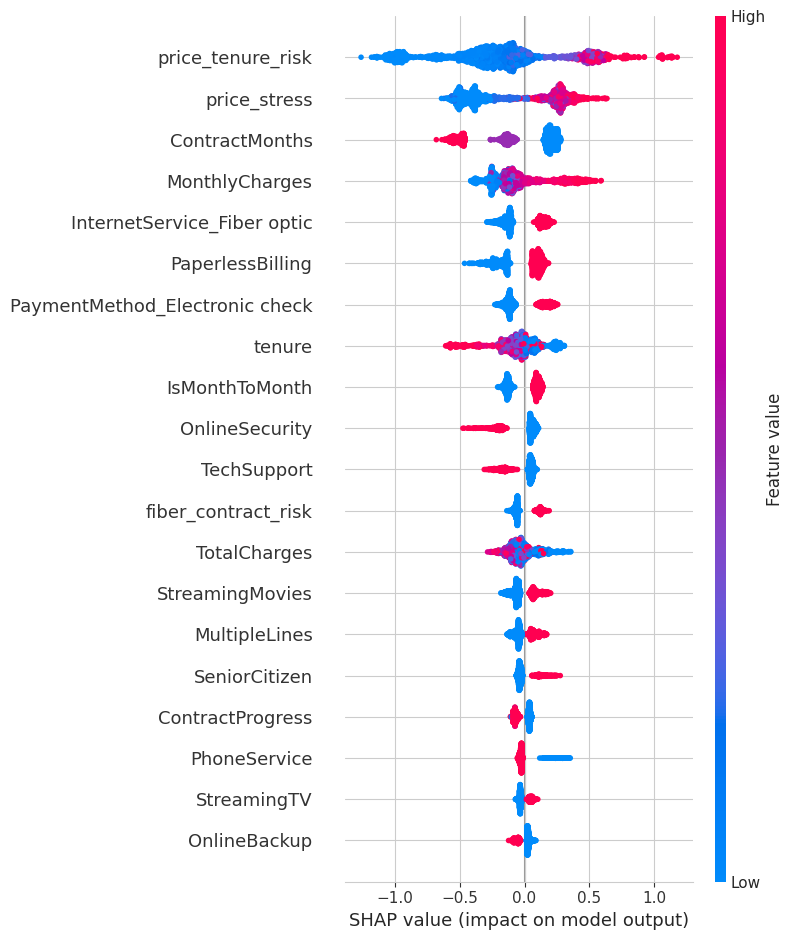

In [84]:
shap.summary_plot(shap_values, X_test)

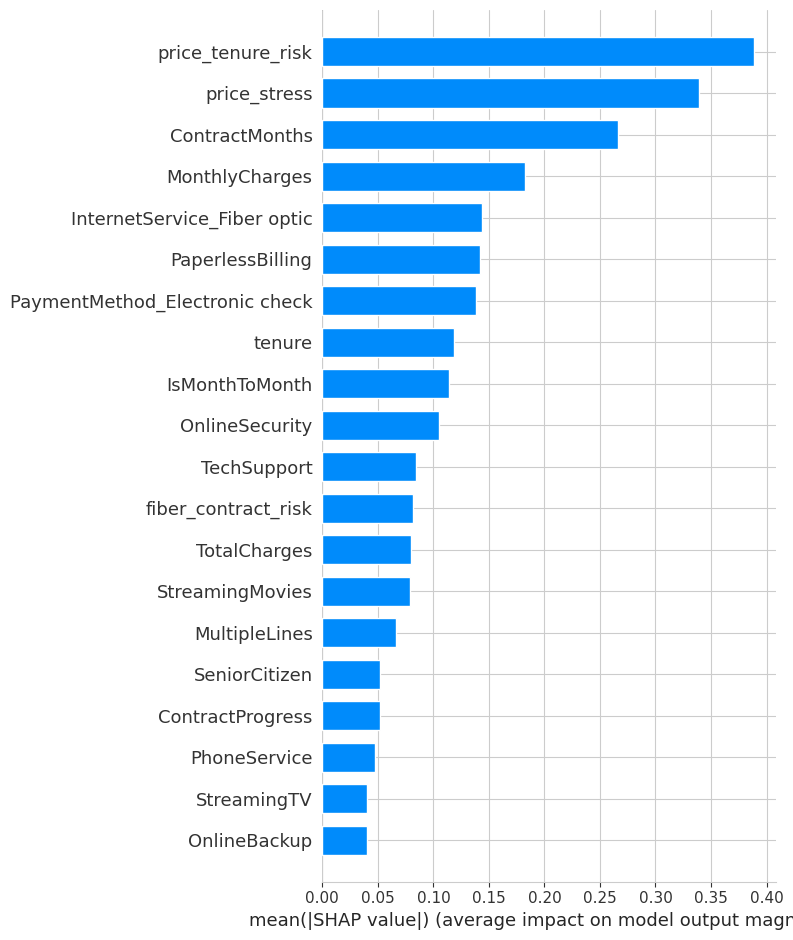

In [85]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

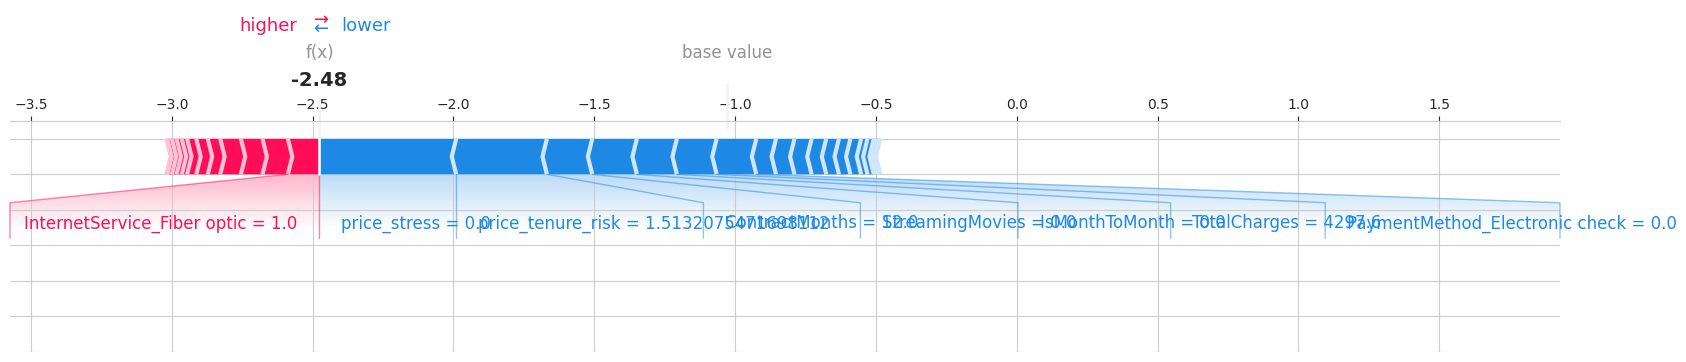

In [86]:
i = 0  # example index

shap.force_plot(
    explainer.expected_value,
    shap_values[i],
    X_test.iloc[i],
    matplotlib=True
)

In [87]:
def explain_customer(model, explainer, X, index, top_n=3):
    
    shap_vals = explainer.shap_values(X.iloc[[index]])[0]
    
    feature_vals = X.iloc[index]
    
    # combine into dataframe
    explanation = []
    
    for feature, shap_val, value in zip(X.columns, shap_vals, feature_vals):
        explanation.append((feature, shap_val, value))
    
    # sort by absolute impact
    explanation = sorted(explanation, key=lambda x: abs(x[1]), reverse=True)
    
    return explanation[:top_n]

In [88]:
top_features = explain_customer(xgb, explainer, X_test, index=0)

for feat, impact, val in top_features:
    print(f"{feat} (value={val}) → impact={impact:.4f}")

price_stress (value=0.0) → impact=-0.4854
price_tenure_risk (value=1.5132075471698112) → impact=-0.3221
ContractMonths (value=12.0) → impact=-0.1610


In [89]:
def explain_text(top_features):
    
    reasons = []
    
    for feat, impact, val in top_features:
        direction = "increases" if impact > 0 else "decreases"
        reasons.append(f"{feat}={val} {direction} churn risk")
    
    return reasons

In [90]:
def full_customer_report(model, explainer, X, index):
    
    proba = model.predict_proba(X.iloc[[index]])[0,1]
    
    if proba < 0.3:
        risk = "Low"
    elif proba < 0.6:
        risk = "Medium"
    else:
        risk = "High"
    
    top_feats = explain_customer(model, explainer, X, index)
    reasons = explain_text(top_feats)
    
    return {
        "probability": proba,
        "risk": risk,
        "reasons": reasons
    }

In [91]:
report = full_customer_report(calibrated_model, explainer, X_test, 10)

print(report)

{'probability': np.float64(1.0), 'risk': 'High', 'reasons': ['price_tenure_risk=42.3 increases churn risk', 'price_stress=84.6 increases churn risk', 'ContractMonths=1.0 increases churn risk']}


In [36]:
data['T_MonthToMonth'] = data['IsMonthToMonth']

data['T_HighCharges'] = (data['MonthlyCharges'] > data['MonthlyCharges'].median()).astype(int)

data['T_Fiber'] = (data['InternetService_Fiber optic'] == 1).astype(int)

data['T_LowTenure'] = (data['tenure'] < 12).astype(int)

In [37]:
print(data['T_Fiber'].value_counts())

T_Fiber
0    3947
1    3096
Name: count, dtype: int64


In [38]:
print(data['T_HighCharges'].value_counts())

T_HighCharges
0    3528
1    3515
Name: count, dtype: int64


In [39]:
print(data['T_LowTenure'].value_counts())

T_LowTenure
0    4974
1    2069
Name: count, dtype: int64


In [40]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 40 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   MultipleLines                          7043 non-null   int64  
 7   OnlineSecurity                         7043 non-null   int64  
 8   OnlineBackup                           7043 non-null   int64  
 9   DeviceProtection                       7043 non-null   int64  
 10  TechSupport                            7043 non-null   int64  
 11  Stre

In [41]:
confounders1 = [
    'Partner',
    'tenure',
    'MonthlyCharges',
    'Dependents',
    'SeniorCitizen',
    'PhoneService',
    'MultipleLines',
    'PaperlessBilling',
    'NumServices',
    'PaymentMethod_Electronic check'
]

In [42]:
confounders2 = [
    'Partner',
    'tenure',
    'ContractMonths',
    'Dependents',
    'SeniorCitizen',
    'PhoneService',
    'MultipleLines',
    'PaperlessBilling',
    'PaymentMethod_Electronic check',
    'InternetService_Fiber optic'
]

In [43]:
confounders3 = [
    'Partner',
    'MonthlyCharges',
    'ContractMonths',
    'Dependents',
    'SeniorCitizen',
    'PhoneService',
    'MultipleLines',
    'PaperlessBilling',
    'PaymentMethod_Electronic check',
    'InternetService_Fiber optic'
]

In [44]:
confounders4 = [
    #'Partner',
    'MonthlyCharges',
    'tenure',
    'ContractMonths',
    #'Dependents',
    #'SeniorCitizen',
    #'NumServices',
    #'PhoneService',
    #'MultipleLines',
    #'PaperlessBilling',
    #'PaymentMethod_Electronic check'
]

In [45]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors


def run_psm(
    data,
    treatment_col,
    confounders,
    outcome_col='Churn',
    n_neighbors=1,
    caliper=None
):
    """
    Performs Propensity Score Matching and returns treatment effect
    
    Parameters:
    - data: dataframe
    - treatment_col: binary treatment column (0/1)
    - confounders: list of columns to use for propensity score
    - outcome_col: target variable (default='Churn')
    - n_neighbors: number of matches
    - caliper: max allowed distance (optional)
    """
    
    df = data.copy().dropna(subset=confounders + [treatment_col, outcome_col])
    
    # Step 1: Estimate propensity scores
    X = df[confounders]
    y = df[treatment_col]
    
    ps_model = LogisticRegression(max_iter=1000)
    ps_model.fit(X, y)
    
    df['propensity_score'] = ps_model.predict_proba(X)[:, 1]
    
    # Step 2: Split treated and control
    treated = df[df[treatment_col] == 1].copy()
    control = df[df[treatment_col] == 0].copy()
    
    # Step 3: Nearest neighbor matching
    nn = NearestNeighbors(n_neighbors=n_neighbors)
    nn.fit(control[['propensity_score']])
    
    distances, indices = nn.kneighbors(treated[['propensity_score']])
    
    # Flatten indices for 1-neighbor case
    matched_control = control.iloc[indices.flatten()].copy()
    
    # Optional: Apply caliper (distance threshold)
    if caliper is not None:
        valid = distances.flatten() <= caliper
        treated = treated.iloc[valid]
        matched_control = matched_control.iloc[valid]
    
    # Step 4: Compute treatment effect
    treated_outcome = treated[outcome_col].mean()
    control_outcome = matched_control[outcome_col].mean()
    
    effect = treated_outcome - control_outcome
    
    return {
        "treatment": treatment_col,
        "treated_mean": treated_outcome,
        "control_mean": control_outcome,
        "effect": effect,
        "n_treated": len(treated),
        "n_control_matched": len(matched_control)
    }

In [46]:
res1 = run_psm(data, 'T_MonthToMonth', confounders1, caliper=0.1)
print(res1)

{'treatment': 'T_MonthToMonth', 'treated_mean': np.float64(0.4270967741935484), 'control_mean': np.float64(0.12283870967741936), 'effect': np.float64(0.304258064516129), 'n_treated': 3875, 'n_control_matched': 3875}


In [47]:
res2 = run_psm(data, 'T_HighCharges', confounders2, caliper=0.1)
print(res2)

{'treatment': 'T_HighCharges', 'treated_mean': np.float64(0.3519203413940256), 'control_mean': np.float64(0.13854907539118066), 'effect': np.float64(0.21337126600284495), 'n_treated': 3515, 'n_control_matched': 3515}


In [48]:
res3 = run_psm(data, 'T_LowTenure', confounders3, caliper=0.05)
print(res3)

{'treatment': 'T_LowTenure', 'treated_mean': np.float64(0.4828419526341228), 'control_mean': np.float64(0.2706621556307395), 'effect': np.float64(0.2121797970033833), 'n_treated': 2069, 'n_control_matched': 2069}


In [49]:
res4 = run_psm(data, 'T_Fiber', confounders4, caliper=0.05)
print(res4)

{'treatment': 'T_Fiber', 'treated_mean': np.float64(0.4189276485788114), 'control_mean': np.float64(0.05781653746770026), 'effect': np.float64(0.3611111111111111), 'n_treated': 3096, 'n_control_matched': 3096}


In [86]:
!pip install dowhy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 10.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.3/204.3 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 39.3 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
  Attempting uninstall: cvxpy
    Found existing installation: cvxpy 1.6.7
    Uninstalling cvxpy-1.6.7:
      Successfully uninstalled cvxpy-1.6.7
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
causalml 0.16.0 requires scipy>=1.16.0, but you have scipy 1.15.3 which is incompatible.


In [88]:
import dowhy
from dowhy import CausalModel

treatments = {
    'T_MonthToMonth': ['Partner','tenure','MonthlyCharges','Dependents','SeniorCitizen',
                       'PhoneService','MultipleLines','PaperlessBilling','NumServices',
                       'PaymentMethod_Electronic check'],
    'T_HighCharges':  ['Partner','tenure','ContractMonths','Dependents','SeniorCitizen',
                       'PhoneService','MultipleLines','PaperlessBilling',
                       'PaymentMethod_Electronic check','InternetService_Fiber optic'],
    'T_LowTenure':    ['Partner','MonthlyCharges','ContractMonths','Dependents','SeniorCitizen',
                       'PhoneService','MultipleLines','PaperlessBilling',
                       'PaymentMethod_Electronic check','InternetService_Fiber optic']
}

dowhy_results = {}

for treatment, confounders in treatments.items():
    cols = confounders + [treatment, 'Churn']
    df_do = data[cols].copy()

    model = CausalModel(
        data=df_do,
        treatment=treatment,
        outcome='Churn',
        common_causes=confounders
    )

    # Identify
    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)

    # Estimate — Linear DML
    estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_matching",
    method_params={
        "num_matches_per_unit": 1,
        "propensity_score_model": GradientBoostingClassifier()
    }
)

    # Refute — placebo test
    refutation = model.refute_estimate(
        identified_estimand, estimate,
        method_name="placebo_treatment_refuter",
        placebo_type="permute",
        num_simulations=20
    )

    dowhy_results[treatment] = {
        'estimate': estimate.value,
        'refutation': refutation
    }

    print(f"\n=== {treatment} ===")
    print(f"Causal Effect : {estimate.value:.4f}")
    print(refutation)


=== T_MonthToMonth ===
Causal Effect : 0.1849
Refute: Use a Placebo Treatment
Estimated effect:0.18486440437313645
New effect:0.00124236830895925
p value:0.452457539892178


=== T_HighCharges ===
Causal Effect : 0.0760
Refute: Use a Placebo Treatment
Estimated effect:0.07596194803350845
New effect:-0.004650007099247481
p value:0.369634591979779


=== T_LowTenure ===
Causal Effect : 0.1120
Refute: Use a Placebo Treatment
Estimated effect:0.11202612523072554
New effect:-0.0026196223200340768
p value:0.4163279800828441



In [50]:
!pip install econml causalml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 55.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 19.9 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 7.7 MB/s eta 0:00:00
  Attempting uninstall: pathos
    Found existing installation: pathos 0.3.2
    Uninstalling pathos-0.3.2:
      Successfully uninstalled pathos-0.3.2
  Attempting uninstall: shap
    Found existing installation: shap 0.50.0
    Uninstalling shap-0.50.0:
      Successfully uninstalled shap-0.50.0


In [52]:
drop_cols = ['Churn', 'T_MonthToMonth', 'T_HighCharges', 'T_Fiber', 'T_LowTenure']
X = data.drop(columns=drop_cols)
Y = data['Churn'].values
treatments = ['T_MonthToMonth', 'T_HighCharges', 'T_LowTenure']

In [54]:
from causalml.inference.meta import BaseSRegressor, BaseTRegressor, BaseXRegressor
from xgboost import XGBRegressor

results = {}

for t in treatments:
    T = data[t].values
    X_t = data.drop(columns=drop_cols + [t] if t not in drop_cols else drop_cols)
    
    # S-Learner
    s = BaseSRegressor(learner=XGBRegressor(n_estimators=100, random_state=42))
    s.fit(X_t, T, Y)
    s_uplift = s.predict(X_t)

    # T-Learner
    t_learner = BaseTRegressor(learner=XGBRegressor(n_estimators=100, random_state=42))
    t_learner.fit(X_t, T, Y)
    t_uplift = t_learner.predict(X_t)

    # X-Learner
    x = BaseXRegressor(learner=XGBRegressor(n_estimators=100, random_state=42))
    x.fit(X_t, T, Y)
    x_uplift = x.predict(X_t)

    results[t] = {'S': s_uplift, 'T': t_uplift, 'X': x_uplift}

In [59]:
results[t]

{'S': array([[ 0.        ],
        [-0.00453614],
        [ 0.        ],
        ...,
        [ 0.        ],
        [ 0.        ],
        [ 0.        ]]),
 'T': array([[ 1.70726225e-01],
        [-7.35386740e-04],
        [ 7.38180518e-01],
        ...,
        [-2.30432361e-01],
        [ 5.29627323e-01],
        [-4.42854017e-02]]),
 'X': array([[ 0.32640103],
        [ 0.23325173],
        [-0.0151383 ],
        ...,
        [ 0.3128014 ],
        [ 0.13622453],
        [-0.01742459]])}

In [61]:
from econml.dml import CausalForestDML
from sklearn.ensemble import GradientBoostingRegressor

cf_results = {}

for t in treatments:
    T = data[t].values.reshape(-1, 1)
    
    cf = CausalForestDML(
        model_y=GradientBoostingRegressor(n_estimators=100, random_state=42),
        model_t=GradientBoostingRegressor(n_estimators=100, random_state=42),
        n_estimators=200,
        random_state=42
    )
    cf.fit(Y, T, X=X)
    cf_uplift = cf.effect(X)
    cf_results[t] = cf_uplift


=== T_MonthToMonth ===
S     0.078618
T     0.485749
X     0.158818
CF    0.254622
dtype: float64

=== T_HighCharges ===
S    -0.017104
T     0.868699
X     0.256343
CF    0.517929
dtype: float64

=== T_LowTenure ===
S     0.058852
T     0.340950
X    -0.133848
CF    0.125540
dtype: float64


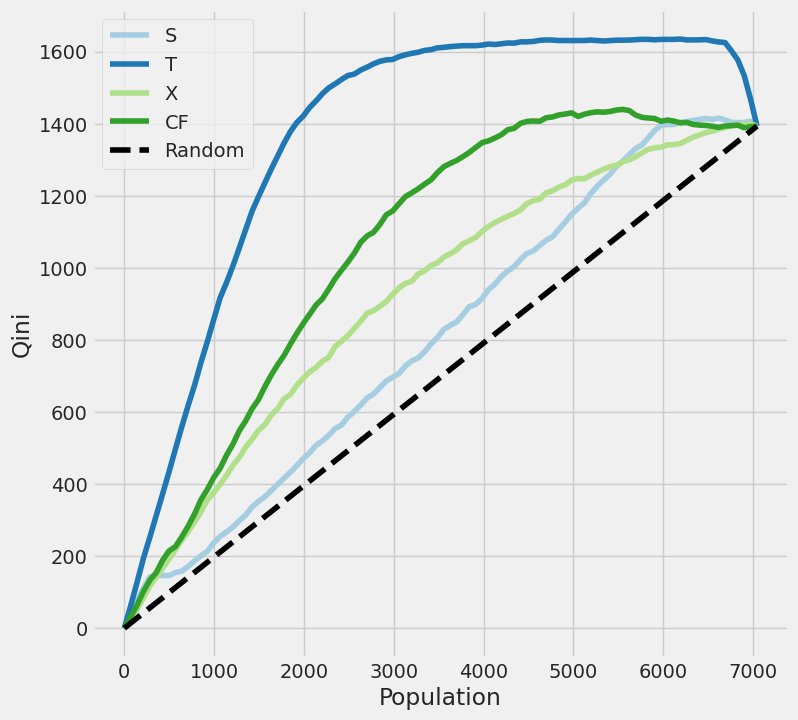

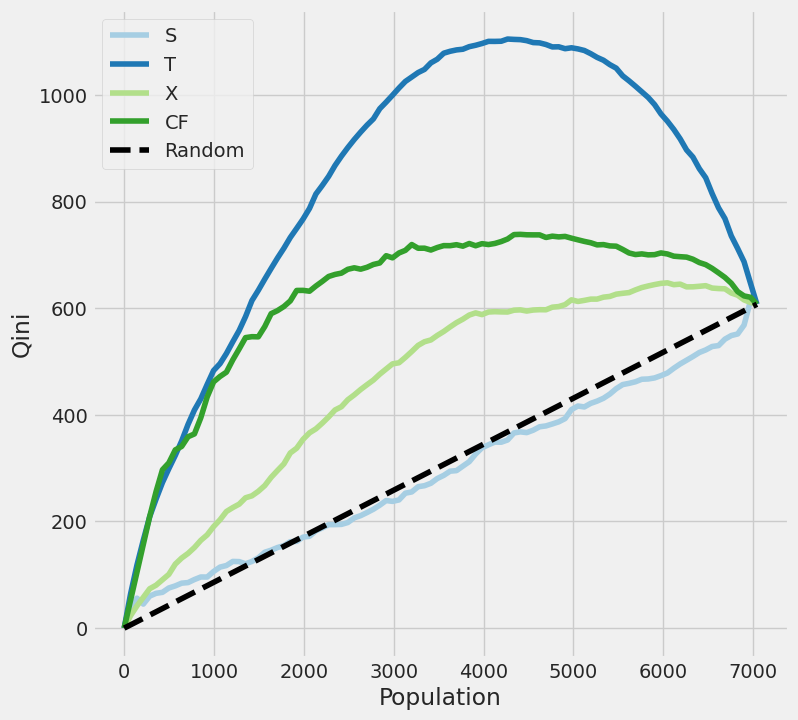

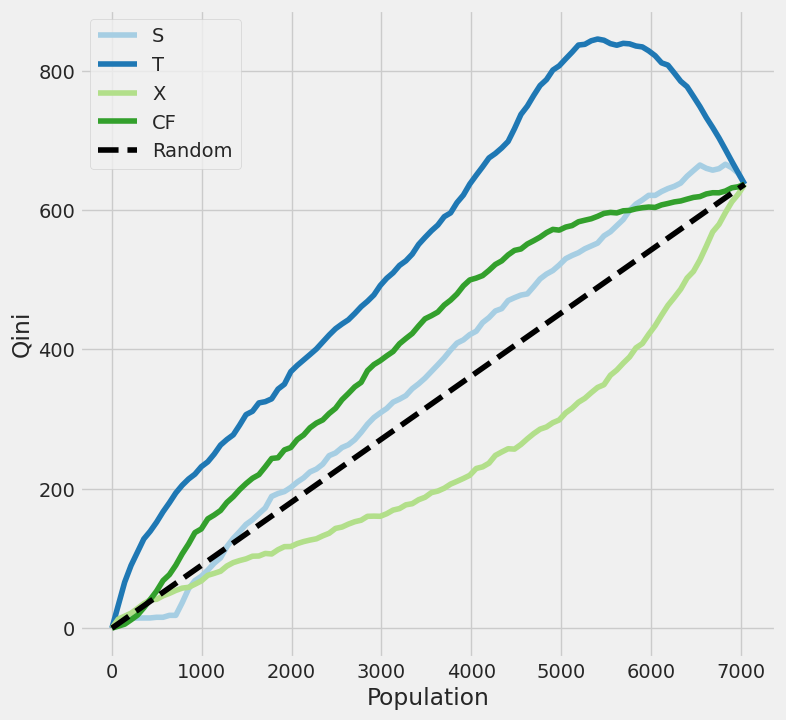

In [63]:
from causalml.metrics import plot_gain, plot_qini, qini_score
import pandas as pd

for t in treatments:
    T = data[t].values
    df_eval = pd.DataFrame({
        'y': Y, 'w': T,
        'S': results[t]['S'].flatten(),
        'T': results[t]['T'].flatten(),
        'X': results[t]['X'].flatten(),
        'CF': cf_results[t].flatten()
    })
    print(f"\n=== {t} ===")
    print(qini_score(df_eval, outcome_col='y', treatment_col='w'))
    plot_qini(df_eval, outcome_col='y', treatment_col='w')

In [64]:
for t in treatments:
    data[f'uplift_X_{t}'] = results[t]['X'].flatten()
    data[f'uplift_CF_{t}'] = cf_results[t].flatten()

# Persuadables (high uplift, would churn if untreated)
data['persuadable'] = (
    (data['uplift_X_T_MonthToMonth'] > 0.1) |
    (data['uplift_X_T_HighCharges'] > 0.1) |
    (data['uplift_X_T_LowTenure'] > 0.1)
)

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split

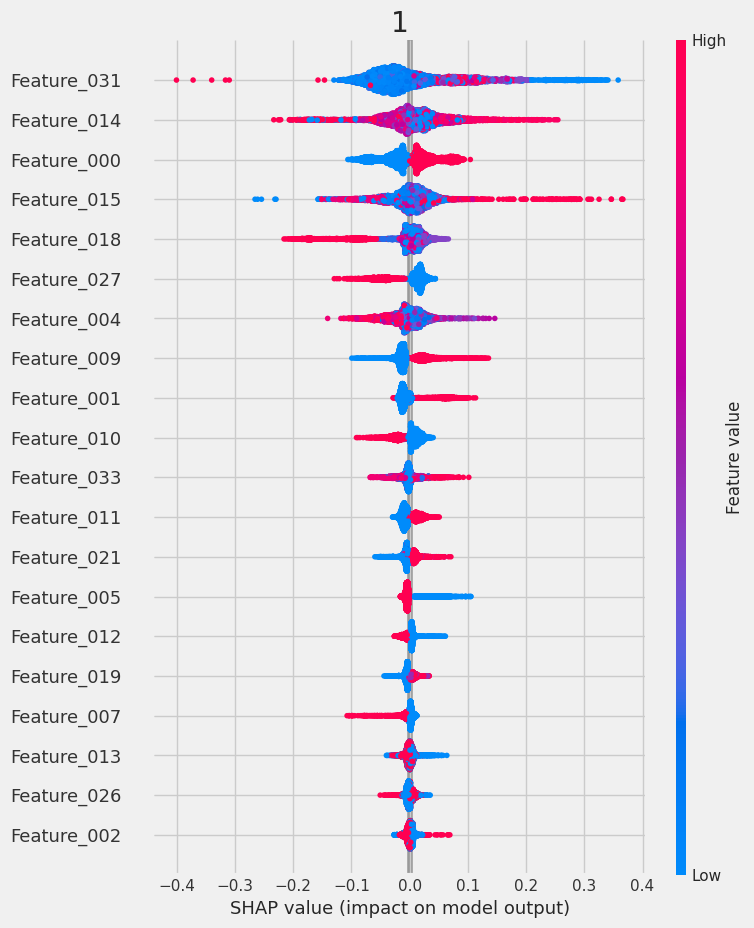

In [77]:
import shap
from xgboost import XGBRegressor

x_model = BaseXRegressor(learner=XGBRegressor())
x_model.fit(X, data['T_MonthToMonth'].values, Y)
tau = x_model.predict(X)
x_model.plot_shap_values(X=X, tau=tau)



In [80]:
import joblib

ensemble_model = joblib.load('/kaggle/input/models/sanskar1120sri/ensemble-model/scikitlearn/default/1/ensemble_model.pkl')

In [81]:
import numpy as np

df_seg = data.copy()
df_seg['uplift_MonthToMonth'] = results['T_MonthToMonth']['X'].flatten()
df_seg['uplift_HighCharges']  = results['T_HighCharges']['X'].flatten()
df_seg['uplift_LowTenure']    = results['T_LowTenure']['X'].flatten()


df_seg['uplift_score'] = df_seg[['uplift_MonthToMonth','uplift_HighCharges','uplift_LowTenure']].mean(axis=1)


df_seg['churn_prob'] = ensemble_model.predict_proba(X)[:, 1]


def segment(row):
    u = row['uplift_score']
    p = row['churn_prob']
    if u > 0.1 and p > 0.3:
        return 'Persuadable'
    elif u <= 0 :
        return 'Sleeping Dog'
    elif p <= 0.3 and u <= 0.1:
        return 'Sure Thing'
    else:
        return 'Lost Cause'

df_seg['segment'] = df_seg.apply(segment, axis=1)

print(df_seg['segment'].value_counts())
print(df_seg.groupby('segment')['churn_prob'].mean())

segment
Sleeping Dog    2889
Lost Cause      1757
Persuadable     1634
Sure Thing       763
Name: count, dtype: int64
segment
Lost Cause      0.272019
Persuadable     0.661874
Sleeping Dog    0.285297
Sure Thing      0.109932
Name: churn_prob, dtype: float64


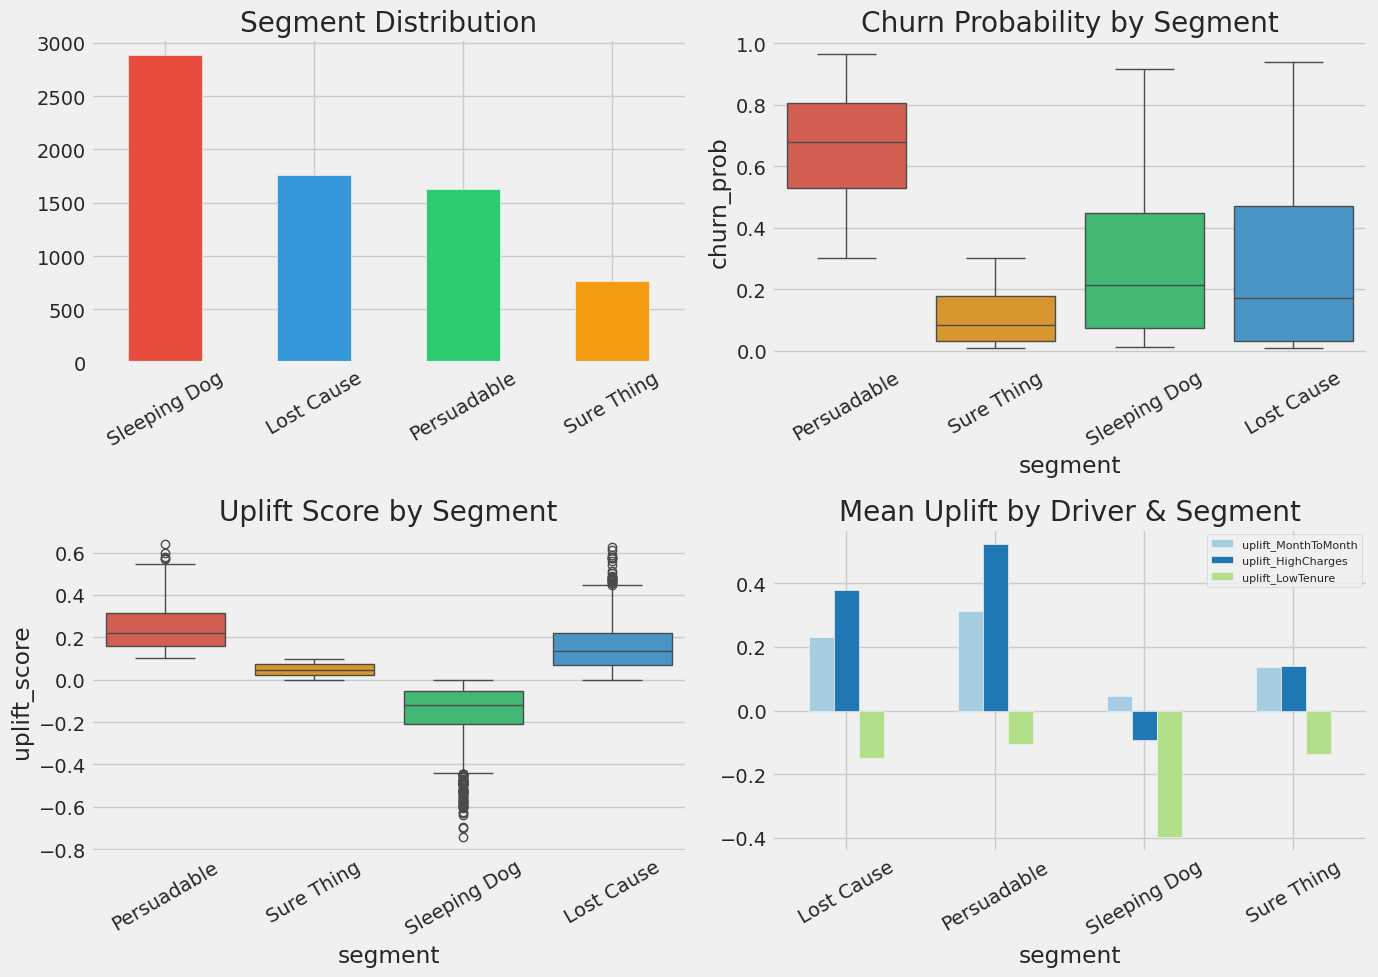

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Segment distribution
df_seg['segment'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#e74c3c','#3498db','#2ecc71','#f39c12'])
axes[0,0].set_title('Segment Distribution')
axes[0,0].set_xlabel('')
axes[0,0].tick_params(axis='x', rotation=30)

# 2. Churn prob by segment
sns.boxplot(data=df_seg, x='segment', y='churn_prob', ax=axes[0,1],
            palette={'Persuadable':'#e74c3c','Lost Cause':'#3498db','Sleeping Dog':'#2ecc71','Sure Thing':'#f39c12'})
axes[0,1].set_title('Churn Probability by Segment')
axes[0,1].tick_params(axis='x', rotation=30)

# 3. Uplift score by segment
sns.boxplot(data=df_seg, x='segment', y='uplift_score', ax=axes[1,0],
            palette={'Persuadable':'#e74c3c','Lost Cause':'#3498db','Sleeping Dog':'#2ecc71','Sure Thing':'#f39c12'})
axes[1,0].set_title('Uplift Score by Segment')
axes[1,0].tick_params(axis='x', rotation=30)

# 4. Uplift drivers by segment
uplift_cols = ['uplift_MonthToMonth','uplift_HighCharges','uplift_LowTenure']
df_seg.groupby('segment')[uplift_cols].mean().plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Mean Uplift by Driver & Segment')
axes[1,1].tick_params(axis='x', rotation=30)
axes[1,1].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Segment Action Recommendations:**

---

### Persuadable (1,634) — *Highest Priority*
- Offer contract upgrade (month-to-month → annual)
- Targeted discount on MonthlyCharges
- Proactive TechSupport / OnlineSecurity upsell
- Goal: reduce price stress + lock into longer contract

---

### Lost Cause (1,757) — *Low ROI*
- Minimal intervention — churn likely regardless
- If budget allows: exit survey / offboarding offer
- Focus on understanding *why* to improve acquisition

---

### Sleeping Dog (2,889) — *Do Not Disturb*
- No retention campaigns — may trigger churn
- Monitor passively
- Any contact should be value-add only (not promotional)

---

### Sure Thing (763) — *Loyalty Program*
- Already low churn risk
- Reward loyalty to maintain satisfaction
- Upsell additional services (StreamingTV, DeviceProtection)



In [83]:
# Assumptions
CAC = 350                  # cost to acquire a new customer
INTERVENTION_COST = 35     # cost per retention offer
DISCOUNT_RATE = 0.10       # 10% discount offered
AVG_RETENTION_MONTHS = 12  # expected months retained if successful

# Merge segment info back
df_roi = df_seg.copy()
df_roi['MonthlyCharges'] = data['MonthlyCharges'].values
df_roi['tenure'] = data['tenure'].values

# Customer Lifetime Value proxy
df_roi['CLV'] = df_roi['MonthlyCharges'] * AVG_RETENTION_MONTHS

# Revenue saved if retained
df_roi['retention_value'] = df_roi['CLV']

# Cost of intervention
df_roi['discount_cost'] = df_roi['MonthlyCharges'] * DISCOUNT_RATE * AVG_RETENTION_MONTHS
df_roi['total_intervention_cost'] = INTERVENTION_COST + df_roi['discount_cost']

# Expected customers saved = segment size × uplift_score (probability of positive response)
df_roi['expected_save_prob'] = df_roi['uplift_score'].clip(0, 1)

# Net value per customer
df_roi['net_value'] = (df_roi['retention_value'] * df_roi['expected_save_prob']) - df_roi['total_intervention_cost']

# Segment-level summary
roi_summary = df_roi.groupby('segment').agg(
    n_customers       = ('net_value', 'count'),
    avg_monthly_charge= ('MonthlyCharges', 'mean'),
    avg_CLV           = ('CLV', 'mean'),
    avg_uplift        = ('uplift_score', 'mean'),
    total_intervention_cost = ('total_intervention_cost', 'sum'),
    total_retention_value   = ('retention_value', 'sum'),
    expected_saved    = ('expected_save_prob', 'sum'),
    total_net_value   = ('net_value', 'sum')
).round(2)

roi_summary['ROI_%'] = ((roi_summary['total_net_value'] / roi_summary['total_intervention_cost']) * 100).round(1)

print(roi_summary[['n_customers','avg_monthly_charge','avg_uplift',
                    'total_intervention_cost','total_net_value','ROI_%']])

# Persuadables only — actionable ROI
p = roi_summary.loc['Persuadable']
print(f"\n>>> Targeting Persuadables only:")
print(f"    Customers targeted : {int(p['n_customers'])}")
print(f"    Total cost         : ${p['total_intervention_cost']:,.0f}")
print(f"    Net value recovered: ${p['total_net_value']:,.0f}")
print(f"    ROI                : {p['ROI_%']}%")
print(f"    vs CAC alternative : {int(p['expected_saved'])} customers × ${CAC} CAC = ${int(p['expected_saved'])*CAC:,.0f} avoided")

              n_customers  avg_monthly_charge  avg_uplift  \
segment                                                     
Lost Cause           1757               48.97        0.15   
Persuadable          1634               76.58        0.24   
Sleeping Dog         2889               71.59       -0.15   
Sure Thing            763               50.00        0.05   

              total_intervention_cost  total_net_value  ROI_%  
segment                                                        
Lost Cause                  164733.58        -34432.60  -20.9  
Persuadable                 207338.98        166262.14   80.2  
Sleeping Dog                349288.50       -349288.50 -100.0  
Sure Thing                   72483.86        -51558.60  -71.1  

>>> Targeting Persuadables only:
    Customers targeted : 1634
    Total cost         : $207,339
    Net value recovered: $166,262
    ROI                : 80.2%
    vs CAC alternative : 398 customers × $350 CAC = $139,300 avoided
